# CS3807 — Deep Learning Laboratory Experiment 6 : End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

## 0. Setup

In [1]:
# ---- Package installs (version-pinned to avoid conflicts) ----
!pip install -q scikit-learn==1.5.2 scikeras==0.13.0

import os, sys, time, glob, random, shutil, json, gc
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TF INFO/WARNING logs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import FontProperties

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, ConfusionMatrixDisplay)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- GPU check ----
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print(e)

# ---- Output directories ----
OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---- Global plotting style: Times New Roman 13, bold axis labels, 150 DPI ----
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 13
mpl.rcParams['savefig.dpi'] = 150
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

def style_axes(ax):
    """Apply bold font to axis labels/ticks per assignment requirement."""
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('serif')
        lbl.set_fontsize(13)
    return ax

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, format='png', bbox_inches='tight')
    print("Saved:", path)
    plt.show()

def clear_mem():
    keras.backend.clear_session()
    gc.collect()

# ---- Cache/memory guard (Kaggle GPU) ----
# We periodically call clear_mem() between heavy trainings to keep
# session memory well under the 20GB ceiling requested.
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 94.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Setup complete.


## 1. Dataset Location — UCI HAR Dataset (Kaggle Input)

In [2]:
# =========================================================================
# >>> USER ACTION REQUIRED <<<
# Set HAR_INPUT_DIR to the Kaggle dataset folder that directly contains
# "train" and "test" subfolders (each with X_test/y_test-style files and
# an "Inertial Signals" directory), matching what you added on Kaggle.
#
# Example:
# HAR_INPUT_DIR = "/kaggle/input/uciml/human-activity-recognition-with-smartphones"
# =========================================================================
HAR_INPUT_DIR = "/kaggle/input/datasets/ashwin271206/har-dataset/UCI HAR Dataset"

def resolve_har_root(base_dir):
    """
    Auto-detects whether 'train'/'test' folders sit directly under base_dir,
    or one level deeper inside a nested 'UCI HAR Dataset' style folder.
    Returns the directory that directly contains train/ and test/.
    """
    direct_train = os.path.join(base_dir, "train")
    direct_test = os.path.join(base_dir, "test")
    if os.path.isdir(direct_train) and os.path.isdir(direct_test):
        return base_dir

    # Search one or two levels deep for a folder containing both train/ and test/
    for dirpath, dirnames, _ in os.walk(base_dir):
        if "train" in dirnames and "test" in dirnames:
            return dirpath

    raise FileNotFoundError(
        f"Could not find 'train' and 'test' folders under {base_dir}. "
        "Please check HAR_INPUT_DIR."
    )

HAR_ROOT = resolve_har_root(HAR_INPUT_DIR)

assert os.path.isdir(os.path.join(HAR_ROOT, "train", "Inertial Signals")), (
    f"'Inertial Signals' folder not found under {HAR_ROOT}/train. "
    "Please verify the dataset contains raw inertial signal files, "
    "not just the precomputed 561-feature CSVs."
)

print("Using HAR_ROOT:", HAR_ROOT)
print("train/ contents:", os.listdir(os.path.join(HAR_ROOT, "train")))
print("test/ contents :", os.listdir(os.path.join(HAR_ROOT, "test")))

Using HAR_ROOT: /kaggle/input/datasets/ashwin271206/har-dataset/UCI HAR Dataset
train/ contents: ['X_train.txt', 'Inertial Signals', 'subject_train.txt', 'y_train.txt']
test/ contents : ['subject_test.txt', 'Inertial Signals', 'y_test.txt', 'X_test.txt']


## 2. Preprocessing — Load Raw Inertial Signals, Window, Normalize, Split

In [3]:
# Raw inertial signal file prefixes (9 channels total)
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_signals(subset):
    """subset = 'train' or 'test'. Returns X: (N,128,9)"""
    sig_dir = os.path.join(HAR_ROOT, subset, "Inertial Signals")
    signals = []
    for name in SIGNAL_NAMES:
        fpath = os.path.join(sig_dir, f"{name}_{subset}.txt")
        arr = np.loadtxt(fpath)          # (N, 128)
        signals.append(arr)
    X = np.stack(signals, axis=-1)       # (N, 128, 9)
    return X

def load_labels(subset):
    fpath = os.path.join(HAR_ROOT, subset, f"y_{subset}.txt")
    y = np.loadtxt(fpath).astype(int)    # values 1..6
    return y - 1                         # zero-index -> 0..5

# ---- 1. Load raw inertial signals ----
X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full  = load_signals("test")
y_test_full  = load_labels("test")

print("Raw train shape:", X_train_full.shape, "Raw test shape:", X_test_full.shape)

# ---- 2 & 3. Windows already 128x9 with one label each (native UCI format) ----

# ---- Recommended lab subset: first 1500-3000 windows, balanced classes ----
def balanced_subset(X, y, n_total=2400, seed=SEED):
    rng = np.random.RandomState(seed)
    classes = np.unique(y)
    per_class = n_total // len(classes)
    idx_all = []
    for c in classes:
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        idx_all.append(idx_c[:per_class])
    idx_all = np.concatenate(idx_all)
    rng.shuffle(idx_all)
    return X[idx_all], y[idx_all]

X_sub, y_sub = balanced_subset(X_train_full, y_train_full, n_total=3000)
print("Balanced training-pool subset shape:", X_sub.shape)
print("Class distribution (subset):", {ACTIVITY_NAMES[c+1]: int((y_sub == c).sum()) for c in np.unique(y_sub)})

# ---- 4. Labels already encoded as integers 0..5 ----

# ---- 6. Train / Validation / Test split: 70/15/15 ----
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# ---- 5. Normalize using TRAIN statistics only ----
N_train, T_STEPS, F_CH = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F_CH))

def apply_scaler(X):
    Ns, T, F = X.shape
    Xs = scaler.transform(X.reshape(-1, F)).reshape(Ns, T, F)
    return Xs

X_train = apply_scaler(X_train)
X_val   = apply_scaler(X_val)
X_test  = apply_scaler(X_test)

NUM_CLASSES = len(ACTIVITY_NAMES)

# ---- 7. Verify class distribution & print expected preprocessing output ----
print("\nInput tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {F_CH}")
print(f"Sequence length: {T_STEPS}")

print("\nClass distribution:")
for split_name, y_split in [("train", y_train), ("val", y_val), ("test", y_test)]:
    dist = {ACTIVITY_NAMES[c+1]: int((y_split == c).sum()) for c in range(NUM_CLASSES)}
    print(f"  {split_name}: {dist}")

Raw train shape: (7352, 128, 9) Raw test shape: (2947, 128, 9)
Balanced training-pool subset shape: (3000, 128, 9)
Class distribution (subset): {'WALKING': 500, 'WALKING_UPSTAIRS': 500, 'WALKING_DOWNSTAIRS': 500, 'SITTING': 500, 'STANDING': 500, 'LAYING': 500}

Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution:
  train: {'WALKING': 350, 'WALKING_UPSTAIRS': 350, 'WALKING_DOWNSTAIRS': 350, 'SITTING': 350, 'STANDING': 350, 'LAYING': 350}
  val: {'WALKING': 75, 'WALKING_UPSTAIRS': 75, 'WALKING_DOWNSTAIRS': 75, 'SITTING': 75, 'STANDING': 75, 'LAYING': 75}
  test: {'WALKING': 75, 'WALKING_UPSTAIRS': 75, 'WALKING_DOWNSTAIRS': 75, 'SITTING': 75, 'STANDING': 75, 'LAYING': 75}


## 3. Temporal Data Visualization

Saved: outputs/figures/plot1_sensor_signal_vs_time.png


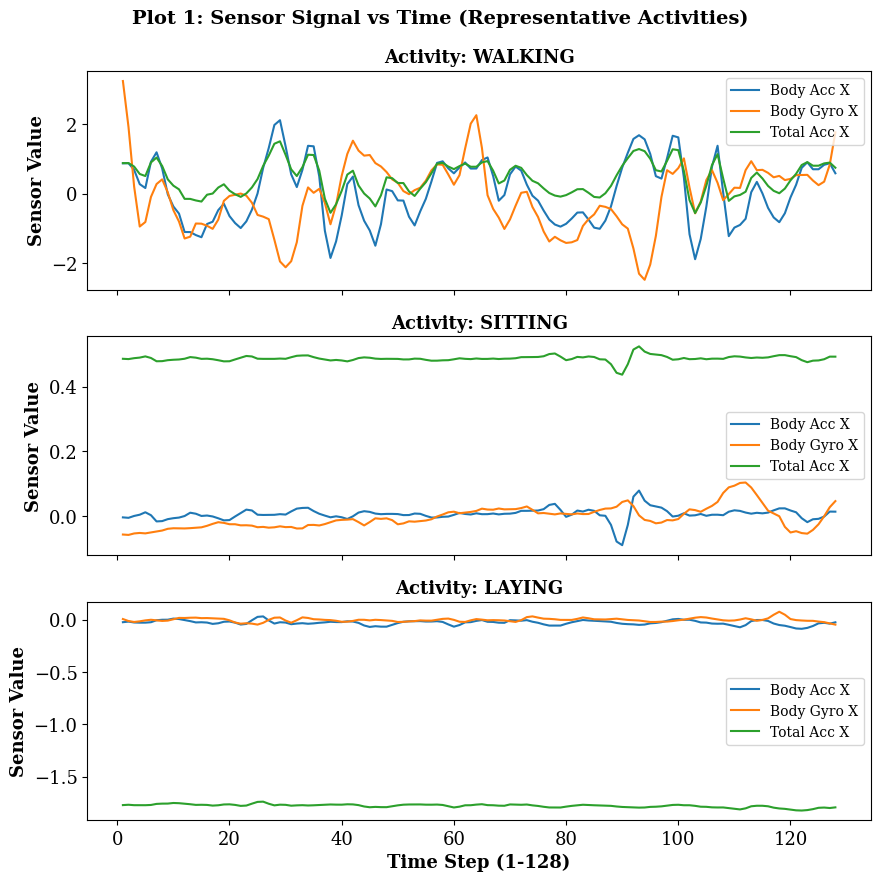

In [4]:
# Plot 1: Sensor signal vs time — 3 representative channels, 3 different activity classes
channels_to_plot = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x
channel_labels = ["Body Acc X", "Body Gyro X", "Total Acc X"]
classes_to_plot = [0, 3, 5]   # WALKING, SITTING, LAYING

fig, axes = plt.subplots(len(classes_to_plot), 1, figsize=(9, 9), sharex=True)
for row, cls in enumerate(classes_to_plot):
    idx = np.where(y_train == cls)[0][0]
    seq = X_train[idx]
    for ch, lab in zip(channels_to_plot, channel_labels):
        axes[row].plot(range(1, T_STEPS + 1), seq[:, ch], label=lab, linewidth=1.5)
    axes[row].set_title(f"Activity: {ACTIVITY_NAMES[cls+1]}", fontsize=13, fontweight='bold')
    axes[row].set_ylabel("Sensor Value", fontweight='bold', fontsize=13)
    axes[row].legend(fontsize=10)
    style_axes(axes[row])
axes[-1].set_xlabel("Time Step (1-128)", fontweight='bold', fontsize=13)
fig.suptitle("Plot 1: Sensor Signal vs Time (Representative Activities)", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot1_sensor_signal_vs_time.png")

## 4. Backpropagation Through Time — Numerical Exercise

In [5]:
# Manual BPTT numerical exercise as specified in the manual
x_vals = [0.5, 0.7, 0.2]
h_prev = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

h_manual = []
h = h_prev
for x in x_vals:
    h = np.tanh(Wx * x + Wh * h + b)
    h_manual.append(h)

print("Manually computed hidden states:")
for i, h_val in enumerate(h_manual, start=1):
    print(f"  h{i} = {h_val:.6f}")

# Verify using a TensorFlow SimpleRNN cell with identical weights
cell = layers.SimpleRNNCell(1, activation='tanh')
cell.build(input_shape=(None, 1))
cell.set_weights([
    np.array([[Wx]], dtype=np.float32),   # kernel (input -> hidden)
    np.array([[Wh]], dtype=np.float32),   # recurrent kernel (hidden -> hidden)
    np.array([b], dtype=np.float32),      # bias
])

h_state = tf.zeros((1, 1))
h_program = []
for x in x_vals:
    x_in = tf.constant([[x]], dtype=tf.float32)
    out, [h_state] = cell(x_in, [h_state])
    h_program.append(float(out.numpy()[0, 0]))

print("\nProgram-computed hidden states (TensorFlow SimpleRNNCell):")
for i, h_val in enumerate(h_program, start=1):
    print(f"  h{i} = {h_val:.6f}")

print("\nDifference (manual - program):")
for i, (a, b_) in enumerate(zip(h_manual, h_program), start=1):
    print(f"  h{i}: {abs(a - b_):.8f}")

Manually computed hidden states:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958


I0000 00:00:1789966895.717418      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789966895.720471      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Program-computed hidden states (TensorFlow SimpleRNNCell):
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958

Difference (manual - program):
  h1: 0.00000001
  h2: 0.00000000
  h3: 0.00000003


## 5. Vanilla RNN Implementation and Training

In [6]:
def build_model(recurrent_type, units=32, input_shape=(T_STEPS, F_CH), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)
    if recurrent_type == "RNN":
        x = layers.SimpleRNN(units)(inp)
    elif recurrent_type == "LSTM":
        x = layers.LSTM(units)(inp)
    elif recurrent_type == "GRU":
        x = layers.GRU(units)(inp)
    else:
        raise ValueError(recurrent_type)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def train_model(model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32, verbose=1):
    start = time.time()
    history = model.fit(X_train, y_train,
                         validation_data=(X_val, y_val),
                         epochs=epochs, batch_size=batch_size,
                         verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed

clear_mem()
rnn_model = build_model("RNN", units=32)
rnn_model.summary()
history_rnn, time_rnn = train_model(rnn_model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32)
print(f"RNN training time: {time_rnn:.2f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
19/66 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2081 - loss: 1.8213

I0000 00:00:1789966901.178486     138 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3724 - loss: 1.5298 - val_accuracy: 0.5000 - val_loss: 1.2730
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5276 - loss: 1.1694 - val_accuracy: 0.5956 - val_loss: 1.0191
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5614 - loss: 1.0320 - val_accuracy: 0.5956 - val_loss: 1.0386
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6071 - loss: 0.9096 - val_accuracy: 0.6556 - val_loss: 0.8002
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6471 - loss: 0.8012 - val_accuracy: 0.6778 - val_loss: 0.7439
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6676 - loss: 0.7499 - val_accuracy: 0.6867 - val_loss: 0.6954
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6686 - loss: 0.7528 - val_accuracy: 0.6444 - val_loss: 0.8608
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6486 - loss: 0.8265 - val_accuracy: 0.6867 - val_loss: 0.

## 6. LSTM Implementation and Training

In [7]:
clear_mem()
lstm_model = build_model("LSTM", units=32)
lstm_model.summary()
history_lstm, time_lstm = train_model(lstm_model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32)
print(f"LSTM training time: {time_lstm:.2f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4281 - loss: 1.5545 - val_accuracy: 0.5689 - val_loss: 1.2197
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6057 - loss: 1.0887 - val_accuracy: 0.6778 - val_loss: 0.8957
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6576 - loss: 0.8175 - val_accuracy: 0.6867 - val_loss: 0.7344
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7243 - loss: 0.6752 - val_accuracy: 0.7844 - val_loss: 0.5907
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7981 - loss: 0.5554 - val_accuracy: 0.8311 - val_loss: 0.4841
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8633 - loss: 0.4346 - val_accuracy: 0.9089 - val_loss: 0.3257
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8971 - loss: 0.3616 - val_accuracy: 0.9022 - val_loss: 0.3118
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9071 - loss: 0.3060 - val_accuracy: 0.9022 - val_

## 7. GRU Implementation and Training

In [8]:
clear_mem()
gru_model = build_model("GRU", units=32)
gru_model.summary()
history_gru, time_gru = train_model(gru_model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32)
print(f"GRU training time: {time_gru:.2f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3700 - loss: 1.5730 - val_accuracy: 0.5333 - val_loss: 1.3788
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5862 - loss: 1.2494 - val_accuracy: 0.6267 - val_loss: 1.0504
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6519 - loss: 0.8981 - val_accuracy: 0.7044 - val_loss: 0.7322
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7238 - loss: 0.6770 - val_accuracy: 0.7578 - val_loss: 0.5834
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7919 - loss: 0.5639 - val_accuracy: 0.8311 - val_loss: 0.4936
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8395 - loss: 0.4523 - val_accuracy: 0.8822 - val_loss: 0.3673
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8957 - loss: 0.3343 - val_accuracy: 0.9200 - val_loss: 0.2464
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9167 - loss: 0.2567 - val_accuracy: 0.9267 - val_los

## 8. Training and Validation Loss/Accuracy Curves (RNN, LSTM, GRU)

Saved: outputs/figures/plot2_loss_curves.png


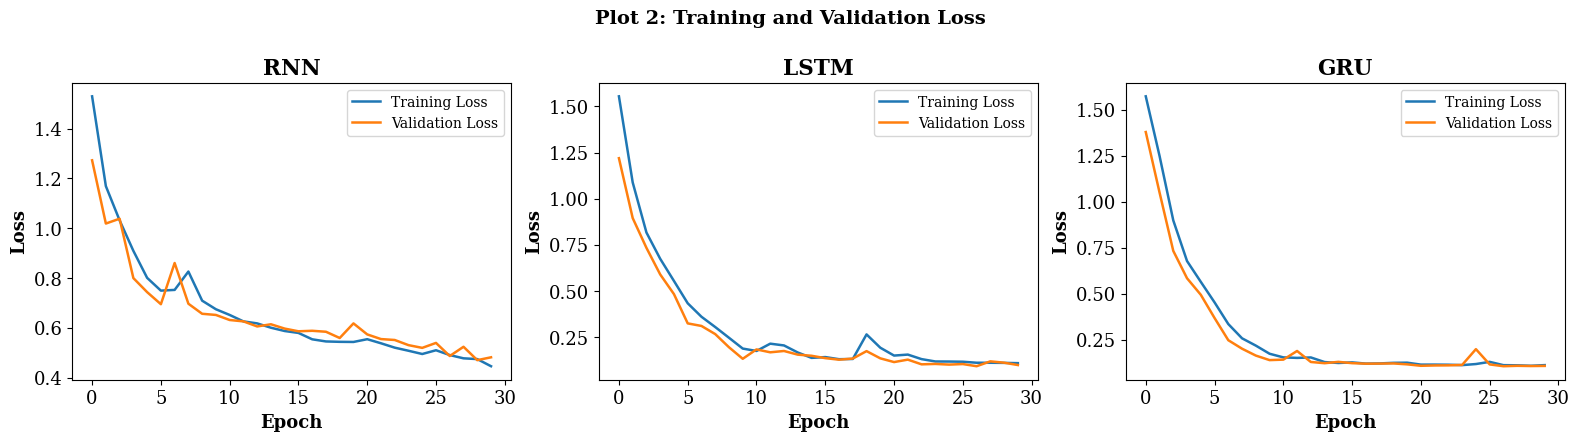

Saved: outputs/figures/plot3_accuracy_curves.png


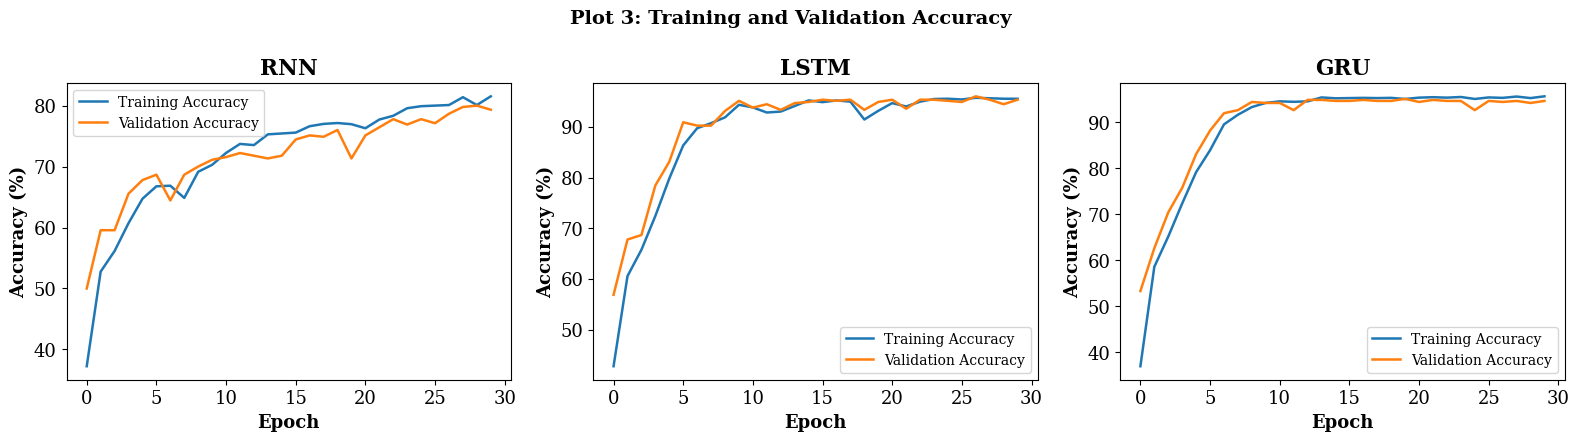

In [9]:
histories = {"RNN": history_rnn, "LSTM": history_lstm, "GRU": history_gru}

# Plot 2: Training & Validation Loss (one figure, 3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'], label='Training Loss', linewidth=1.8)
    ax.plot(hist.history['val_loss'], label='Validation Loss', linewidth=1.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Epoch", fontweight='bold', fontsize=13)
    ax.set_ylabel("Loss", fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    style_axes(ax)
fig.suptitle("Plot 2: Training and Validation Loss", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot2_loss_curves.png")

# Plot 3: Training & Validation Accuracy (%) (one figure, 3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(np.array(hist.history['accuracy']) * 100, label='Training Accuracy', linewidth=1.8)
    ax.plot(np.array(hist.history['val_accuracy']) * 100, label='Validation Accuracy', linewidth=1.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Epoch", fontweight='bold', fontsize=13)
    ax.set_ylabel("Accuracy (%)", fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    style_axes(ax)
fig.suptitle("Plot 3: Training and Validation Accuracy", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot3_accuracy_curves.png")

## 9. Performance Evaluation on Test Set

In [10]:
def evaluate_model(model, X_test, y_test, name):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    n_params = model.count_params()
    return {
        "model": name, "accuracy": acc, "precision": prec * 100, "recall": rec * 100,
        "f1": f1 * 100, "params": n_params, "y_pred": y_pred
    }

results_rnn = evaluate_model(rnn_model, X_test, y_test, "RNN")
results_lstm = evaluate_model(lstm_model, X_test, y_test, "LSTM")
results_gru = evaluate_model(gru_model, X_test, y_test, "GRU")

results_rnn["train_time"] = time_rnn
results_lstm["train_time"] = time_lstm
results_gru["train_time"] = time_gru

perf_table = pd.DataFrame([
    {"Metric": "Accuracy (%)", "RNN": results_rnn["accuracy"], "LSTM": results_lstm["accuracy"], "GRU": results_gru["accuracy"]},
    {"Metric": "Macro Precision (%)", "RNN": results_rnn["precision"], "LSTM": results_lstm["precision"], "GRU": results_gru["precision"]},
    {"Metric": "Macro Recall (%)", "RNN": results_rnn["recall"], "LSTM": results_lstm["recall"], "GRU": results_gru["recall"]},
    {"Metric": "Macro F1 (%)", "RNN": results_rnn["f1"], "LSTM": results_lstm["f1"], "GRU": results_gru["f1"]},
    {"Metric": "Parameters", "RNN": results_rnn["params"], "LSTM": results_lstm["params"], "GRU": results_gru["params"]},
    {"Metric": "Training Time (s)", "RNN": results_rnn["train_time"], "LSTM": results_lstm["train_time"], "GRU": results_gru["train_time"]},
])
perf_table.to_csv(os.path.join(OUT_DIR, "performance_table.csv"), index=False)
perf_table

,Metric,RNN,LSTM,GRU
0,Accuracy (%),82.000000,95.555556,94.666667
1,Macro Precision (%),81.884581,95.652931,95.295444
2,Macro Recall (%),82.000000,95.555556,94.666667
3,Macro F1 (%),81.881214,95.554919,94.600153
4,Parameters,1974.000000,6006.000000,4758.000000
5,Training Time (s),27.445665,23.489902,20.881721


## 10. Confusion Matrix Analysis

Saved: outputs/figures/plot4_confusion_matrices.png


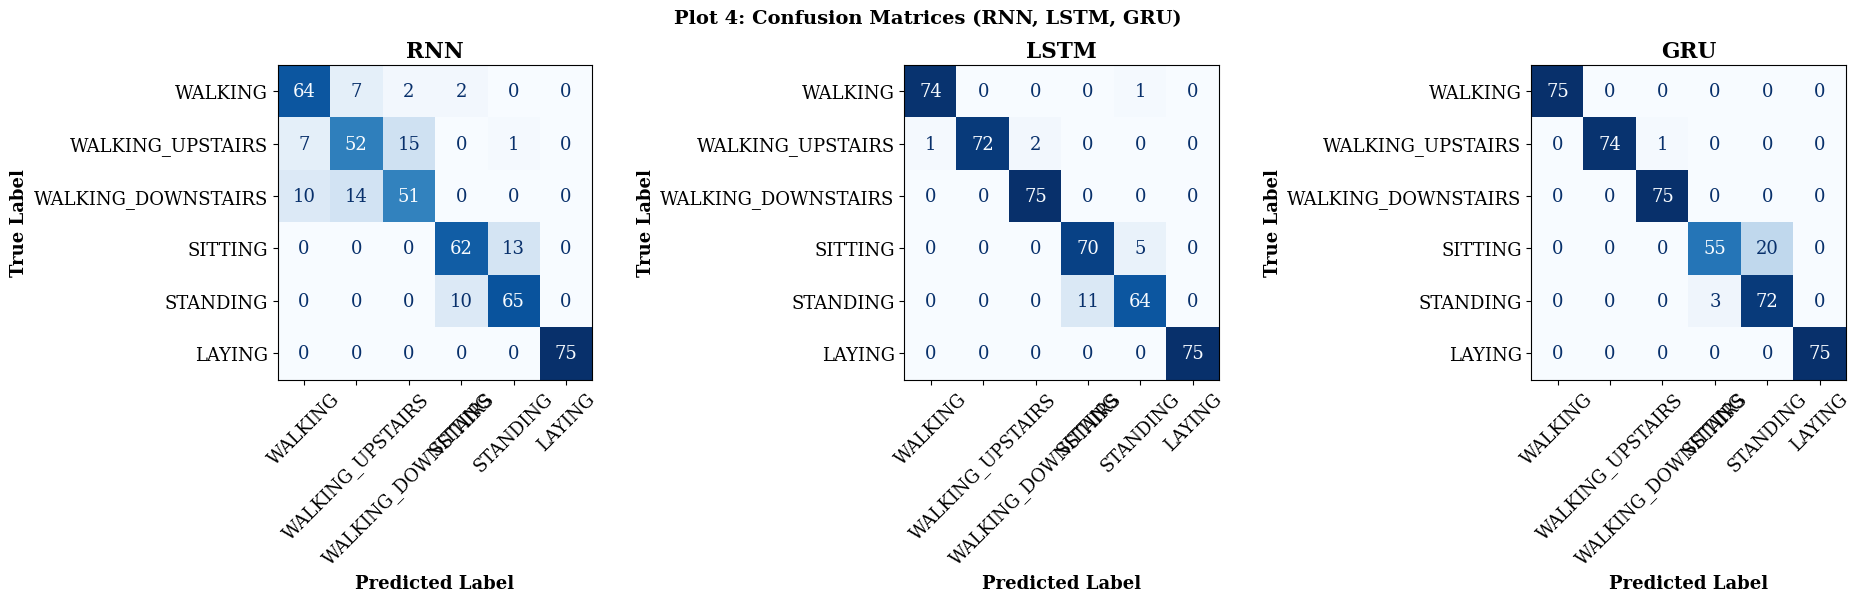

In [11]:
# Plot 4: Confusion Matrix for each model
class_labels = [ACTIVITY_NAMES[i] for i in range(1, NUM_CLASSES + 1)]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, res in zip(axes, [results_rnn, results_lstm, results_gru]):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(res["model"], fontweight='bold')
    ax.set_xlabel("Predicted Label", fontweight='bold', fontsize=13)
    ax.set_ylabel("True Label", fontweight='bold', fontsize=13)
    style_axes(ax)
fig.suptitle("Plot 4: Confusion Matrices (RNN, LSTM, GRU)", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot4_confusion_matrices.png")

## 11. RNN vs. LSTM vs. GRU — Comparison Table and Bar Plot

,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time,27.45s,23.49s,20.88s
9,Test F1-score,81.88,95.55,94.60


Saved: outputs/figures/plot5_model_comparison.png


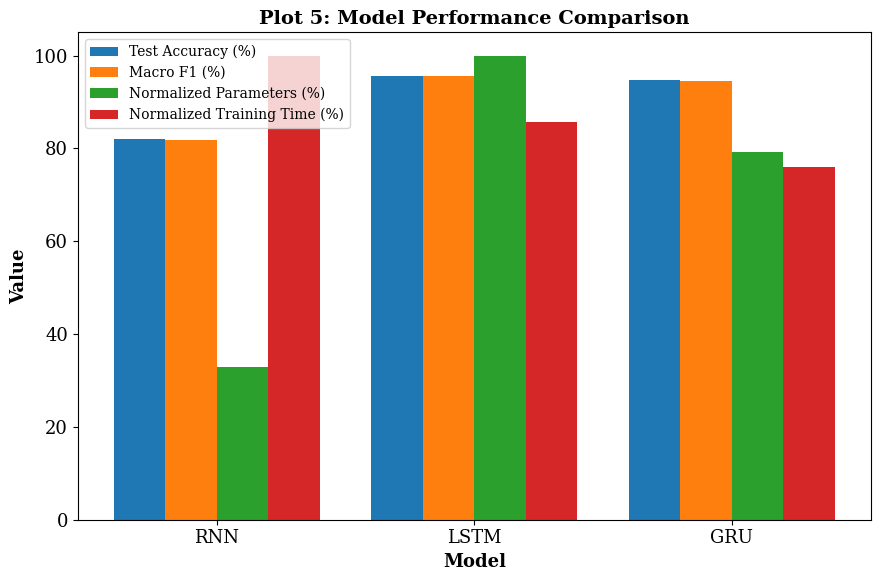

In [12]:
comparison_table = pd.DataFrame([
    {"Property": "Hidden state", "RNN": "Yes", "LSTM": "Yes", "GRU": "Yes"},
    {"Property": "Cell state", "RNN": "No", "LSTM": "Yes", "GRU": "No"},
    {"Property": "Forget gate", "RNN": "No", "LSTM": "Yes", "GRU": "No"},
    {"Property": "Input gate", "RNN": "No", "LSTM": "Yes", "GRU": "No"},
    {"Property": "Output gate", "RNN": "No", "LSTM": "Yes", "GRU": "No"},
    {"Property": "Update gate", "RNN": "No", "LSTM": "No", "GRU": "Yes"},
    {"Property": "Reset gate", "RNN": "No", "LSTM": "No", "GRU": "Yes"},
    {"Property": "Parameters", "RNN": results_rnn["params"], "LSTM": results_lstm["params"], "GRU": results_gru["params"]},
    {"Property": "Training time", "RNN": f'{results_rnn["train_time"]:.2f}s', "LSTM": f'{results_lstm["train_time"]:.2f}s', "GRU": f'{results_gru["train_time"]:.2f}s'},
    {"Property": "Test F1-score", "RNN": f'{results_rnn["f1"]:.2f}', "LSTM": f'{results_lstm["f1"]:.2f}', "GRU": f'{results_gru["f1"]:.2f}'},
])
comparison_table.to_csv(os.path.join(OUT_DIR, "comparison_table.csv"), index=False)
display(comparison_table)

# Plot 5: Model Performance Comparison bar plot
models_names = ["RNN", "LSTM", "GRU"]
acc_vals = [results_rnn["accuracy"], results_lstm["accuracy"], results_gru["accuracy"]]
f1_vals = [results_rnn["f1"], results_lstm["f1"], results_gru["f1"]]
params_vals = [results_rnn["params"], results_lstm["params"], results_gru["params"]]
params_norm = [100 * p / max(params_vals) for p in params_vals]
time_vals = [results_rnn["train_time"], results_lstm["train_time"], results_gru["train_time"]]
time_norm = [100 * t / max(time_vals) for t in time_vals]

x = np.arange(len(models_names))
width = 0.2
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - 1.5*width, acc_vals, width, label='Test Accuracy (%)')
ax.bar(x - 0.5*width, f1_vals, width, label='Macro F1 (%)')
ax.bar(x + 0.5*width, params_norm, width, label='Normalized Parameters (%)')
ax.bar(x + 1.5*width, time_norm, width, label='Normalized Training Time (%)')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_xlabel("Model", fontweight='bold', fontsize=13)
ax.set_ylabel("Value", fontweight='bold', fontsize=13)
ax.set_title("Plot 5: Model Performance Comparison", fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
style_axes(ax)
fig.tight_layout()
savefig(fig, "plot5_model_comparison.png")

## 12. Effect of Sequence Length (T = 32, 64, 128)

T= 32 | RNN   | Macro F1 = 80.34%
T= 32 | LSTM  | Macro F1 = 94.42%
T= 32 | GRU   | Macro F1 = 92.10%
T= 64 | RNN   | Macro F1 = 85.90%
T= 64 | LSTM  | Macro F1 = 95.33%
T= 64 | GRU   | Macro F1 = 92.99%
T=128 | RNN   | Macro F1 = 80.22%
T=128 | LSTM  | Macro F1 = 93.08%
T=128 | GRU   | Macro F1 = 95.31%


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,80.344582,94.420657,92.098553
1,64,85.899175,95.332592,92.993542
2,128,80.218618,93.082882,95.309230


Saved: outputs/figures/plot6_sequence_length_vs_f1.png


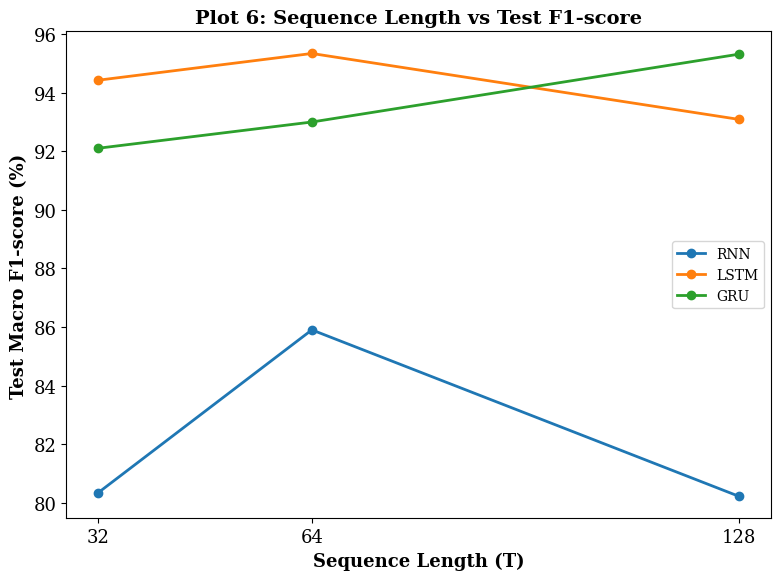

In [13]:
def truncate_seq(X, T):
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {"RNN": [], "LSTM": [], "GRU": []}

for T_len in seq_lengths:
    Xtr_t = truncate_seq(X_train, T_len)
    Xval_t = truncate_seq(X_val, T_len)
    Xte_t = truncate_seq(X_test, T_len)

    for rtype in ["RNN", "LSTM", "GRU"]:
        clear_mem()
        m = build_model(rtype, units=32, input_shape=(T_len, F_CH))
        m.fit(Xtr_t, y_train, validation_data=(Xval_t, y_val),
              epochs=30, batch_size=32, verbose=0)
        y_prob = m.predict(Xte_t, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
        seqlen_results[rtype].append(f1 * 100)
        print(f"T={T_len:3d} | {rtype:5s} | Macro F1 = {f1*100:.2f}%")

seqlen_table = pd.DataFrame({
    "Sequence Length": seq_lengths,
    "RNN F1": seqlen_results["RNN"],
    "LSTM F1": seqlen_results["LSTM"],
    "GRU F1": seqlen_results["GRU"],
})
seqlen_table.to_csv(os.path.join(OUT_DIR, "sequence_length_table.csv"), index=False)
display(seqlen_table)

# Plot 6: Sequence Length vs Test F1-score
fig, ax = plt.subplots(figsize=(8, 6))
for rtype in ["RNN", "LSTM", "GRU"]:
    ax.plot(seq_lengths, seqlen_results[rtype], marker='o', linewidth=2, label=rtype)
ax.set_xlabel("Sequence Length (T)", fontweight='bold', fontsize=13)
ax.set_ylabel("Test Macro F1-score (%)", fontweight='bold', fontsize=13)
ax.set_title("Plot 6: Sequence Length vs Test F1-score", fontweight='bold', fontsize=14)
ax.set_xticks(seq_lengths)
ax.legend(fontsize=10)
style_axes(ax)
fig.tight_layout()
savefig(fig, "plot6_sequence_length_vs_f1.png")

## 13. Video Understanding — UCF101 Subset Discovery (Auto-Detect)

In [14]:
# UCF101 dataset (pevogam/ucf101 on Kaggle): one folder per action class
# directly under UCF-101/, e.g. UCF-101/Basketball/v_Basketball_g01_c01.avi.
# Class is taken directly from the containing folder name (no split-level
# nesting in this dataset), and we restrict to five specific classes as
# requested, with a fixed number of videos sampled per class.
VIDEO_EXTS = (".avi", ".mp4", ".mov", ".mkv")
UCF101_ROOT = "/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101"

SELECTED_CLASSES = ["Biking", "CricketShot", "TennisSwing", "TableTennisShot", "PushUps"]
VIDEOS_PER_CLASS = 40

def discover_videos(root=UCF101_ROOT, classes=SELECTED_CLASSES, videos_per_class=VIDEOS_PER_CLASS, seed=SEED):
    rng_local = np.random.RandomState(seed)
    rows = []
    for cls in classes:
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            print(f"WARNING: class folder not found: {cls_dir}")
            continue
        vids = [f for f in os.listdir(cls_dir) if f.lower().endswith(VIDEO_EXTS)]
        vids.sort()
        if not vids:
            print(f"WARNING: no video files found in {cls_dir}")
            continue
        n_take = min(len(vids), videos_per_class)
        chosen = rng_local.choice(vids, size=n_take, replace=False)
        for fn in chosen:
            rows.append((os.path.join(cls_dir, fn), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

video_df = discover_videos()
print(f"Discovered {len(video_df)} videos across {video_df['label'].nunique() if len(video_df) else 0} classes.")
display(video_df.groupby("label").size() if len(video_df) else video_df)

assert len(video_df) > 0, (
    f"No video files were found under {UCF101_ROOT} for classes {SELECTED_CLASSES}. "
    "Please verify UCF101_ROOT and the class folder names."
)

video_class_names = sorted(video_df["label"].unique().tolist())
video_label_encoder = LabelEncoder().fit(video_class_names)
video_df["label_id"] = video_label_encoder.transform(video_df["label"])
NUM_VIDEO_CLASSES = len(video_class_names)
print("Selected classes:", video_class_names)

Discovered 200 videos across 5 classes.


label
Biking             40
CricketShot        40
PushUps            40
TableTennisShot    40
TennisSwing        40
dtype: int64

Selected classes: ['Biking', 'CricketShot', 'PushUps', 'TableTennisShot', 'TennisSwing']


## 14. Video Frame Extraction (10 Frames Uniformly Sampled, 224x224x3)

In [15]:
import cv2

FRAMES_PER_VIDEO = 10
FRAME_SIZE = (224, 224)

def extract_frames(video_path, num_frames=FRAMES_PER_VIDEO, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return None
    indices = np.linspace(0, max(total_frames - 1, 0), num_frames).astype(int)
    frames = []
    idx_set = set(indices.tolist())
    current = 0
    frame_map = {}
    while cap.isOpened() and len(frame_map) < len(idx_set):
        ret, frame = cap.read()
        if not ret:
            break
        if current in idx_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frame_map[current] = frame
        current += 1
    cap.release()
    if len(frame_map) < num_frames:
        return None
    frames = [frame_map[i] for i in indices]
    return np.stack(frames, axis=0)  # (num_frames, H, W, 3)

# Extract frames for every discovered video (skip unreadable ones)
video_frames_list = []
video_labels_list = []
video_paths_kept = []
for _, row in video_df.iterrows():
    frames = extract_frames(row["path"])
    if frames is not None:
        video_frames_list.append(frames)
        video_labels_list.append(row["label_id"])
        video_paths_kept.append(row["path"])

video_frames_arr = np.stack(video_frames_list, axis=0)   # (num_videos, 10, 224, 224, 3)
video_labels_arr = np.array(video_labels_list)
print("Extracted frame tensor shape:", video_frames_arr.shape)
print("Number of usable videos:", len(video_labels_arr))

Extracted frame tensor shape: (188, 10, 224, 224, 3)
Number of usable videos: 188


## 15. Visualize Sampled Frames from One Video

Saved: outputs/figures/plot7_video_sample_frames.png


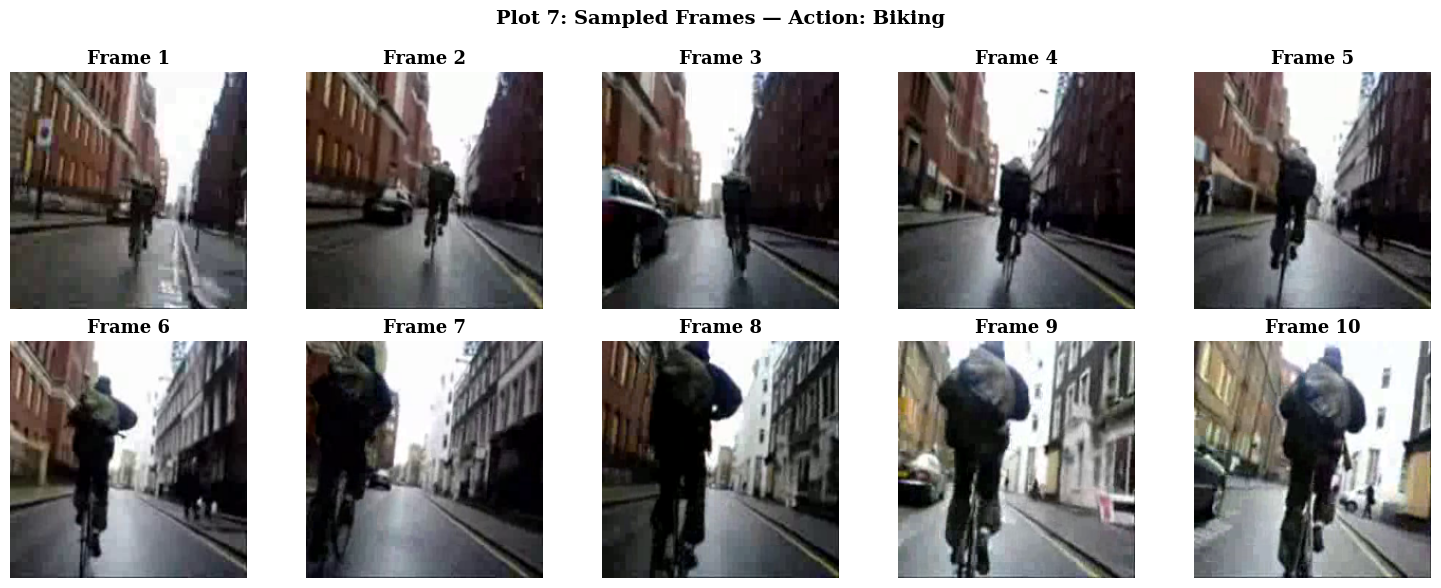

In [16]:
# Plot 7: Video Sample Frames
sample_idx = 0
sample_frames = video_frames_arr[sample_idx]
sample_label = video_label_encoder.inverse_transform([video_labels_arr[sample_idx]])[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_frames[i].astype(np.uint8))
    ax.set_title(f"Frame {i+1}", fontsize=13, fontfamily='serif')
    ax.axis('off')
fig.suptitle(f"Plot 7: Sampled Frames — Action: {sample_label}", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot7_video_sample_frames.png")

## 16. CNN Feature Extraction Using Pretrained MobileNetV2 (Frozen)

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

clear_mem()
base_cnn = MobileNetV2(include_top=False, weights='imagenet',
                        input_shape=(224, 224, 3), pooling='avg')
base_cnn.trainable = False  # Freeze pretrained CNN; do not train from scratch

FEATURE_DIM = base_cnn.output_shape[-1]
print("CNN feature dimension (D):", FEATURE_DIM)

def extract_cnn_features(frames_arr, batch_size=32):
    """frames_arr: (num_videos, 10, 224, 224, 3) -> (num_videos, 10, D)"""
    n_videos, n_frames = frames_arr.shape[0], frames_arr.shape[1]
    flat = frames_arr.reshape(-1, 224, 224, 3).astype(np.float32)
    flat = preprocess_input(flat)
    feats = base_cnn.predict(flat, batch_size=batch_size, verbose=1)
    feats = feats.reshape(n_videos, n_frames, FEATURE_DIM)
    return feats

video_features = extract_cnn_features(video_frames_arr)
print("Resulting tensor shape supplied to recurrent network:", video_features.shape)

# Free frame memory (large arrays) now that features are extracted
del video_frames_arr
gc.collect()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension (D): 1280
59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 220ms/step
Resulting tensor shape supplied to recurrent network: (188, 10, 1280)


331

## 17. CNN–LSTM / CNN–GRU Model: Train/Val/Test Split and Training

In [18]:
def build_video_model(recurrent_type, units=32, input_shape=(FRAMES_PER_VIDEO, FEATURE_DIM), num_classes=NUM_VIDEO_CLASSES):
    inp = layers.Input(shape=input_shape)
    if recurrent_type == "LSTM":
        x = layers.LSTM(units)(inp)
    elif recurrent_type == "GRU":
        x = layers.GRU(units)(inp)
    else:
        raise ValueError(recurrent_type)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train/val/test split for the video task (stratify if class sizes allow)
try:
    Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
        video_features, video_labels_arr, test_size=0.30, stratify=video_labels_arr, random_state=SEED)
    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_temp, yv_temp, test_size=0.50, stratify=yv_temp, random_state=SEED)
except ValueError:
    # Fall back to non-stratified split if any class has too few samples
    Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
        video_features, video_labels_arr, test_size=0.30, random_state=SEED)
    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_temp, yv_temp, test_size=0.50, random_state=SEED)

print("Video train/val/test shapes:", Xv_train.shape, Xv_val.shape, Xv_test.shape)

VIDEO_RECURRENT_TYPE = "LSTM"  # Selected recurrent architecture for video task (per manual: LSTM or GRU)

clear_mem()
video_model = build_video_model(VIDEO_RECURRENT_TYPE, units=32)
video_model.summary()
video_history, video_train_time = train_model(
    video_model, Xv_train, yv_train, Xv_val, yv_val, epochs=30, batch_size=8)
print(f"Video {VIDEO_RECURRENT_TYPE} training time: {video_train_time:.2f}s")

Video train/val/test shapes: (131, 10, 1280) (28, 10, 1280) (29, 10, 1280)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,229 (657.14 KB)

 Trainable params: 168,229 (657.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6031 - loss: 1.3048 - val_accuracy: 0.9286 - val_loss: 0.8064
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9237 - loss: 0.6381 - val_accuracy: 0.9286 - val_loss: 0.4978
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9313 - loss: 0.3914 - val_accuracy: 1.0000 - val_loss: 0.2675
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9695 - loss: 0.2420 - val_accuracy: 1.0000 - val_loss: 0.2066
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9924 - loss: 0.1695 - val_accuracy: 1.0000 - val_loss: 0.1598
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.1115 - val_accuracy: 1.0000 - val_loss: 0.1097
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0832 - val_accuracy: 1.0000 - val_loss: 0.0925
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0644 - val_accuracy: 1.0000 - v

## 18. Video Training and Validation Curves

Saved: outputs/figures/plot8_video_training_curves.png


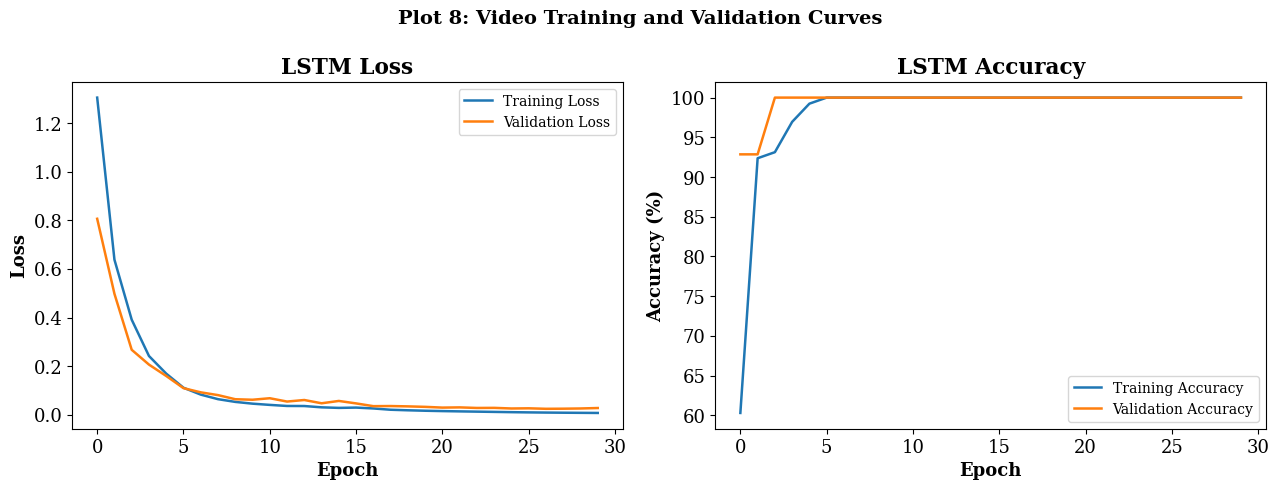

In [19]:
# Plot 8: Video Training/Validation Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(video_history.history['loss'], label='Training Loss', linewidth=1.8)
axes[0].plot(video_history.history['val_loss'], label='Validation Loss', linewidth=1.8)
axes[0].set_xlabel("Epoch", fontweight='bold', fontsize=13)
axes[0].set_ylabel("Loss", fontweight='bold', fontsize=13)
axes[0].set_title(f"{VIDEO_RECURRENT_TYPE} Loss", fontweight='bold')
axes[0].legend(fontsize=10)
style_axes(axes[0])

axes[1].plot(np.array(video_history.history['accuracy']) * 100, label='Training Accuracy', linewidth=1.8)
axes[1].plot(np.array(video_history.history['val_accuracy']) * 100, label='Validation Accuracy', linewidth=1.8)
axes[1].set_xlabel("Epoch", fontweight='bold', fontsize=13)
axes[1].set_ylabel("Accuracy (%)", fontweight='bold', fontsize=13)
axes[1].set_title(f"{VIDEO_RECURRENT_TYPE} Accuracy", fontweight='bold')
axes[1].legend(fontsize=10)
style_axes(axes[1])

fig.suptitle("Plot 8: Video Training and Validation Curves", fontweight='bold', fontsize=14)
fig.tight_layout()
savefig(fig, "plot8_video_training_curves.png")

## 19. Video Model Evaluation and Confusion Matrix

Video LSTM Test Accuracy : 89.66%
Video LSTM Macro Precision: 89.81%
Video LSTM Macro Recall   : 89.33%
Video LSTM Macro F1        : 89.31%

Per-video predictions on the test set (29 videos):
  [  1] Predicted class : Biking          | Actual class : Biking          | Confidence : 0.97
  [  2] Predicted class : Biking          | Actual class : Biking          | Confidence : 0.99
  [  3] Predicted class : Biking          | Actual class : Biking          | Confidence : 0.99
  [  4] Predicted class : TableTennisShot | Actual class : TableTennisShot | Confidence : 0.99
  [  5] Predicted class : TennisSwing     | Actual class : TennisSwing     | Confidence : 0.99
  [  6] Predicted class : PushUps         | Actual class : PushUps         | Confidence : 0.98
  [  7] Predicted class : TableTennisShot | Actual class : TableTennisShot | Confidence : 1.00
  [  8] Predicted class : CricketShot     | Actual class : CricketShot     | Confidence : 0.98
  [  9] Predicted class : CricketShot     | Actu

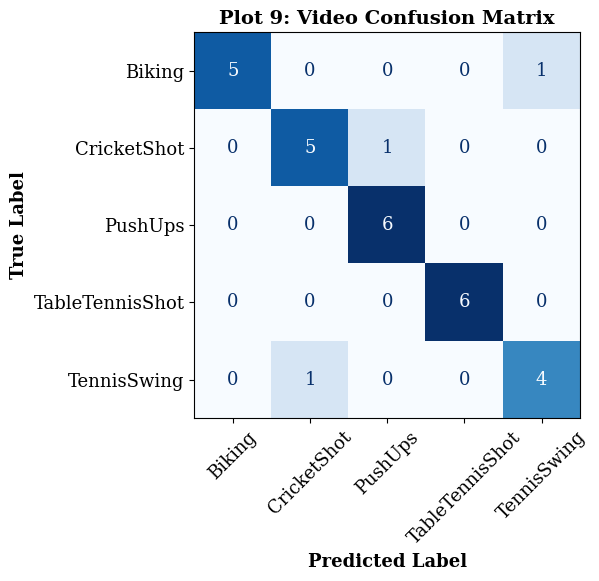

In [20]:
yv_prob = video_model.predict(Xv_test, verbose=0)
yv_pred = np.argmax(yv_prob, axis=1)
yv_conf = np.max(yv_prob, axis=1)

video_acc = accuracy_score(yv_test, yv_pred) * 100
video_prec, video_rec, video_f1, _ = precision_recall_fscore_support(
    yv_test, yv_pred, average='macro', zero_division=0)

print(f"Video {VIDEO_RECURRENT_TYPE} Test Accuracy : {video_acc:.2f}%")
print(f"Video {VIDEO_RECURRENT_TYPE} Macro Precision: {video_prec*100:.2f}%")
print(f"Video {VIDEO_RECURRENT_TYPE} Macro Recall   : {video_rec*100:.2f}%")
print(f"Video {VIDEO_RECURRENT_TYPE} Macro F1        : {video_f1*100:.2f}%")

# Prediction display for every video in the test set
# (confidence values come directly from the trained model, not manually entered)
print(f"\nPer-video predictions on the test set ({len(yv_test)} videos):")
for i in range(len(yv_test)):
    pred_name = video_label_encoder.inverse_transform([yv_pred[i]])[0]
    true_name = video_label_encoder.inverse_transform([yv_test[i]])[0]
    print(f"  [{i+1:3d}] Predicted class : {pred_name:15s} | Actual class : {true_name:15s} | Confidence : {yv_conf[i]:.2f}")

# Plot 9: Video Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm_video = confusion_matrix(yv_test, yv_pred, labels=list(range(NUM_VIDEO_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_video, display_labels=video_class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_xlabel("Predicted Label", fontweight='bold', fontsize=13)
ax.set_ylabel("True Label", fontweight='bold', fontsize=13)
ax.set_title("Plot 9: Video Confusion Matrix", fontweight='bold', fontsize=14)
style_axes(ax)
fig.tight_layout()
savefig(fig, "plot9_video_confusion_matrix.png")

video_params = video_model.count_params()

## 20. Sequence-to-Sequence Learning — Synthetic Reversal Dataset

In [21]:
SEQ_LEN = 4
VOCAB_MIN, VOCAB_MAX = 1, 9   # integers 1-9
NUM_SAMPLES = 5000

PAD_TOKEN = 0
SOS_TOKEN = 10
VOCAB_SIZE = 11  # 0=PAD, 1-9=digits, 10=SOS

rng = np.random.RandomState(SEED)

def generate_reversal_data(n_samples, seq_len):
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1].copy()
    return X, Y

X_seq, Y_seq = generate_reversal_data(NUM_SAMPLES, SEQ_LEN)
print("Example input :", X_seq[0])
print("Example output:", Y_seq[0])

# Decoder input: SOS + target[:-1] (teacher forcing during training)
decoder_input = np.concatenate(
    [np.full((NUM_SAMPLES, 1), SOS_TOKEN), Y_seq[:, :-1]], axis=1)

Xs_train, Xs_temp, dec_train, dec_temp, Ys_train, Ys_temp = train_test_split(
    X_seq, decoder_input, Y_seq, test_size=0.30, random_state=SEED)
Xs_val, Xs_test, dec_val, dec_test, Ys_val, Ys_test = train_test_split(
    Xs_temp, dec_temp, Ys_temp, test_size=0.50, random_state=SEED)

print("Seq2seq train/val/test sizes:", len(Xs_train), len(Xs_val), len(Xs_test))

Example input : [7 4 8 5]
Example output: [5 8 4 7]
Seq2seq train/val/test sizes: 3500 750 750


## 21. Encoder–Decoder (Seq2Seq) Model: Build and Train

In [22]:
EMB_DIM = 32
ENC_UNITS = 64

def build_seq2seq_model():
    # Encoder
    encoder_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
    enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True)(encoder_inputs)
    _, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
    dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True)
    dec_emb = dec_emb_layer(decoder_inputs)
    decoder_lstm = layers.LSTM(ENC_UNITS, return_sequences=True, return_state=True)
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
    decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax')
    decoder_outputs = decoder_dense(decoder_outputs)

    model = models.Model([encoder_inputs, decoder_inputs], decoder_outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clear_mem()
seq2seq_model = build_seq2seq_model()
seq2seq_model.summary()

seq2seq_history = seq2seq_model.fit(
    [Xs_train, dec_train], Ys_train,
    validation_data=([Xs_val, dec_val], Ys_val),
    epochs=30, batch_size=64, verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        352 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4)         │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 32)     │        352 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     24,832 │ embedding[0][0],  │
│                     │ (None, 64),       │            │ not_equal[0][0]   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 4, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4, 11)     │        715 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2349 - loss: 2.1923 - val_accuracy: 0.3517 - val_loss: 1.7928
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4002 - loss: 1.5133 - val_accuracy: 0.4697 - val_loss: 1.2661
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6356 - loss: 0.9717 - val_accuracy: 0.8393 - val_loss: 0.6368
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9434 - loss: 0.4069 - val_accuracy: 0.9800 - val_loss: 0.2538
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9910 - loss: 0.1827 - val_accuracy: 0.9963 - val_loss: 0.1376
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9978 - loss: 0.1069 - val_accuracy: 0.9980 - val_loss: 0.0904
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9990 - loss: 0.0722 - val_accuracy: 0.9993 - val_loss: 0.0669
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9996 - loss: 0.0524 - val_accuracy: 1.0000 - val_loss

## 22. Sequence-to-Sequence Evaluation — Token and Sequence Accuracy

In [23]:
# Greedy inference: build separate encoder/decoder inference models
encoder_inputs = seq2seq_model.input[0]
enc_emb_layer = seq2seq_model.layers[2]
encoder_lstm_layer = seq2seq_model.layers[4]
_, state_h, state_c = encoder_lstm_layer.output
encoder_infer_model = models.Model(encoder_inputs, [state_h, state_c])

decoder_inputs_single = layers.Input(shape=(1,), name="dec_infer_input")
dec_state_h_in = layers.Input(shape=(ENC_UNITS,))
dec_state_c_in = layers.Input(shape=(ENC_UNITS,))
dec_emb_layer_ref = seq2seq_model.layers[3]
decoder_lstm_ref = seq2seq_model.layers[5]
decoder_dense_ref = seq2seq_model.layers[6]

dec_emb_single = dec_emb_layer_ref(decoder_inputs_single)
dec_out_single, dec_h_out, dec_c_out = decoder_lstm_ref(
    dec_emb_single, initial_state=[dec_state_h_in, dec_state_c_in])
dec_pred_single = decoder_dense_ref(dec_out_single)

decoder_infer_model = models.Model(
    [decoder_inputs_single, dec_state_h_in, dec_state_c_in],
    [dec_pred_single, dec_h_out, dec_c_out])

def decode_sequence(input_seq):
    h, c = encoder_infer_model.predict(input_seq[np.newaxis, :], verbose=0)
    target_tok = np.array([[SOS_TOKEN]])
    output_tokens = []
    for _ in range(SEQ_LEN):
        pred, h, c = decoder_infer_model.predict([target_tok, h, c], verbose=0)
        next_tok = int(np.argmax(pred[0, -1, :]))
        output_tokens.append(next_tok)
        target_tok = np.array([[next_tok]])
    return output_tokens

# Evaluate on test set
correct_tokens, total_tokens = 0, 0
correct_sequences = 0
sample_rows = []
for i in range(len(Xs_test)):
    pred_seq = decode_sequence(Xs_test[i])
    true_seq = Ys_test[i].tolist()
    correct_tokens += sum(p == t for p, t in zip(pred_seq, true_seq))
    total_tokens += SEQ_LEN
    if pred_seq == true_seq:
        correct_sequences += 1
    if i < 5:
        sample_rows.append({
            "Sample": i + 1,
            "Input Sequence": Xs_test[i].tolist(),
            "Predicted Output": pred_seq,
        })

token_accuracy = correct_tokens / total_tokens
sequence_accuracy = correct_sequences / len(Xs_test)

print(f"Token Accuracy    : {token_accuracy*100:.2f}%")
print(f"Sequence Accuracy : {sequence_accuracy*100:.2f}%")
print(f"Final Training Loss  : {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {seq2seq_history.history['val_loss'][-1]:.4f}")

seq2seq_sample_table = pd.DataFrame(sample_rows)
seq2seq_sample_table.to_csv(os.path.join(OUT_DIR, "seq2seq_samples.csv"), index=False)
display(seq2seq_sample_table)

Token Accuracy    : 100.00%
Sequence Accuracy : 100.00%
Final Training Loss  : 0.0030
Final Validation Loss: 0.0037


,Sample,Input Sequence,Predicted Output
0,1,"[4, 9, 8, 6]","[6, 8, 9, 4]"
1,2,"[4, 3, 5, 9]","[9, 5, 3, 4]"
2,3,"[9, 3, 8, 1]","[1, 8, 3, 9]"
3,4,"[9, 8, 6, 3]","[3, 6, 8, 9]"
4,5,"[3, 7, 3, 9]","[9, 3, 7, 3]"


## 23. Consolidated Results

In [24]:
consolidated_table = pd.DataFrame([
    {"Model": "RNN", "Accuracy": results_rnn["accuracy"], "Precision": results_rnn["precision"],
     "Recall": results_rnn["recall"], "F1": results_rnn["f1"], "Parameters": results_rnn["params"]},
    {"Model": "LSTM", "Accuracy": results_lstm["accuracy"], "Precision": results_lstm["precision"],
     "Recall": results_lstm["recall"], "F1": results_lstm["f1"], "Parameters": results_lstm["params"]},
    {"Model": "GRU", "Accuracy": results_gru["accuracy"], "Precision": results_gru["precision"],
     "Recall": results_gru["recall"], "F1": results_gru["f1"], "Parameters": results_gru["params"]},
    {"Model": f"CNN-{VIDEO_RECURRENT_TYPE}", "Accuracy": video_acc, "Precision": video_prec * 100,
     "Recall": video_rec * 100, "F1": video_f1 * 100, "Parameters": video_params},
])
consolidated_table.to_csv(os.path.join(OUT_DIR, "consolidated_results.csv"), index=False)
display(consolidated_table)

seq2seq_results_table = pd.DataFrame([
    {"Metric": "Token Accuracy (%)", "Value": token_accuracy * 100},
    {"Metric": "Sequence Accuracy (%)", "Value": sequence_accuracy * 100},
    {"Metric": "Training Loss", "Value": seq2seq_history.history['loss'][-1]},
    {"Metric": "Validation Loss", "Value": seq2seq_history.history['val_loss'][-1]},
])
seq2seq_results_table.to_csv(os.path.join(OUT_DIR, "seq2seq_results.csv"), index=False)
display(seq2seq_results_table)

,Model,Accuracy,Precision,Recall,F1,Parameters
0,RNN,82.000000,81.884581,82.000000,81.881214,1974
1,LSTM,95.555556,95.652931,95.555556,95.554919,6006
2,GRU,94.666667,95.295444,94.666667,94.600153,4758
3,CNN-LSTM,89.655172,89.809524,89.333333,89.310023,168229


,Metric,Value
0,Token Accuracy (%),100.000000
1,Sequence Accuracy (%),100.000000
2,Training Loss,0.002983
3,Validation Loss,0.003674


## 24. Additional Exercises

### 24.1 Exercise 1 — Effect of Recurrent Units (16 vs 32 vs 64)

In [25]:
unit_variants = [16, 32, 64]
ex1_results = []

for u in unit_variants:
    for rtype in ["RNN", "LSTM", "GRU"]:
        clear_mem()
        m = build_model(rtype, units=u)
        start = time.time()
        m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=0)
        elapsed = time.time() - start
        y_prob = m.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        acc = accuracy_score(y_test, y_pred) * 100
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
        ex1_results.append({
            "Model": rtype, "Units": u, "Accuracy (%)": acc, "F1 (%)": f1 * 100,
            "Parameters": m.count_params(), "Training Time (s)": elapsed
        })
        print(f"{rtype:5s} units={u:3d} | Acc={acc:.2f}% F1={f1*100:.2f}% Params={m.count_params()} Time={elapsed:.1f}s")

ex1_table = pd.DataFrame(ex1_results)
ex1_table.to_csv(os.path.join(OUT_DIR, "exercise1_units_effect.csv"), index=False)
display(ex1_table)

RNN   units= 16 | Acc=74.00% F1=73.85% Params=790 Time=26.9s
LSTM  units= 16 | Acc=94.89% F1=94.87% Params=2038 Time=21.4s
GRU   units= 16 | Acc=93.56% F1=93.51% Params=1670 Time=21.2s
RNN   units= 32 | Acc=81.33% F1=81.37% Params=1974 Time=26.6s
LSTM  units= 32 | Acc=96.00% F1=96.00% Params=6006 Time=21.7s
GRU   units= 32 | Acc=94.67% F1=94.64% Params=4758 Time=21.1s
RNN   units= 64 | Acc=79.11% F1=78.87% Params=5878 Time=27.5s
LSTM  units= 64 | Acc=92.67% F1=92.50% Params=20086 Time=21.6s
GRU   units= 64 | Acc=96.22% F1=96.22% Params=15542 Time=21.3s


,Model,Units,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,RNN,16,74.000000,73.850383,790,26.871181
1,LSTM,16,94.888889,94.873068,2038,21.437704
2,GRU,16,93.555556,93.514325,1670,21.220741
3,RNN,32,81.333333,81.372729,1974,26.595827
4,LSTM,32,96.000000,95.998351,6006,21.668335
5,GRU,32,94.666667,94.642857,4758,21.136827
6,RNN,64,79.111111,78.865770,5878,27.503682
7,LSTM,64,92.666667,92.502234,20086,21.604667
8,GRU,64,96.222222,96.216865,15542,21.337344


### 24.2 Exercise 2 — GRU vs LSTM Using the Same Number of Recurrent Units

In [26]:
# Reuse the units=32 rows generated in Exercise 1 for a direct, controlled comparison
ex2_table = ex1_table[(ex1_table["Units"] == 32) & (ex1_table["Model"].isin(["LSTM", "GRU"]))].reset_index(drop=True)
ex2_table.to_csv(os.path.join(OUT_DIR, "exercise2_gru_vs_lstm.csv"), index=False)
display(ex2_table)

,Model,Units,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,LSTM,32,96.000000,95.998351,6006,21.668335
1,GRU,32,94.666667,94.642857,4758,21.136827


### 24.3 Exercise 3 — Effect of Adding a Second Recurrent Layer

In [27]:
def build_stacked_model(recurrent_type, units=32, input_shape=(T_STEPS, F_CH), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)
    if recurrent_type == "RNN":
        x = layers.SimpleRNN(units, return_sequences=True)(inp)
        x = layers.SimpleRNN(units)(x)
    elif recurrent_type == "LSTM":
        x = layers.LSTM(units, return_sequences=True)(inp)
        x = layers.LSTM(units)(x)
    elif recurrent_type == "GRU":
        x = layers.GRU(units, return_sequences=True)(inp)
        x = layers.GRU(units)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

ex3_results = []
for rtype in ["RNN", "LSTM", "GRU"]:
    clear_mem()
    m = build_stacked_model(rtype, units=32)
    start = time.time()
    m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=0)
    elapsed = time.time() - start
    y_prob = m.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred) * 100
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    ex3_results.append({"Model": f"{rtype} (2-layer)", "Accuracy (%)": acc, "F1 (%)": f1 * 100,
                         "Parameters": m.count_params(), "Training Time (s)": elapsed})
    print(f"{rtype} (2-layer) | Acc={acc:.2f}% F1={f1*100:.2f}%")

ex3_table = pd.DataFrame(ex3_results)
ex3_table.to_csv(os.path.join(OUT_DIR, "exercise3_second_layer.csv"), index=False)
display(ex3_table)

RNN (2-layer) | Acc=90.22% F1=90.22%
LSTM (2-layer) | Acc=96.22% F1=96.22%
GRU (2-layer) | Acc=95.33% F1=95.33%


,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,RNN (2-layer),90.222222,90.218861,4054,43.957802
1,LSTM (2-layer),96.222222,96.216514,14326,31.180722
2,GRU (2-layer),95.333333,95.333126,11094,30.563249


### 24.4 Exercise 4 — Bidirectional LSTM vs. Unidirectional LSTM

In [28]:
def build_bilstm_model(units=32, input_shape=(T_STEPS, F_CH), num_classes=NUM_CLASSES):
    inp = layers.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(units))(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clear_mem()
bilstm_model = build_bilstm_model(units=32)
start = time.time()
bilstm_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=0)
bilstm_time = time.time() - start
y_prob = bilstm_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
bilstm_acc = accuracy_score(y_test, y_pred) * 100
_, _, bilstm_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

ex4_table = pd.DataFrame([
    {"Model": "LSTM (unidirectional)", "Accuracy (%)": results_lstm["accuracy"], "F1 (%)": results_lstm["f1"],
     "Parameters": results_lstm["params"], "Training Time (s)": results_lstm["train_time"]},
    {"Model": "BiLSTM", "Accuracy (%)": bilstm_acc, "F1 (%)": bilstm_f1 * 100,
     "Parameters": bilstm_model.count_params(), "Training Time (s)": bilstm_time},
])
ex4_table.to_csv(os.path.join(OUT_DIR, "exercise4_bilstm_vs_lstm.csv"), index=False)
display(ex4_table)

,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,LSTM (unidirectional),95.555556,95.554919,6006,23.489902
1,BiLSTM,91.333333,90.820556,11894,30.117103


### 24.5 Exercise 5 — Sequence Length vs. Computational Cost

T= 32 | RNN   | Time=17.0s Params=1974
T= 32 | LSTM  | Time=17.0s Params=6006
T= 32 | GRU   | Time=16.2s Params=4758
T= 64 | RNN   | Time=19.4s Params=1974
T= 64 | LSTM  | Time=17.8s Params=6006
T= 64 | GRU   | Time=17.5s Params=4758
T=128 | RNN   | Time=26.3s Params=1974
T=128 | LSTM  | Time=20.9s Params=6006
T=128 | GRU   | Time=20.6s Params=4758
Saved: outputs/figures/exercise5_seqlen_vs_cost.png


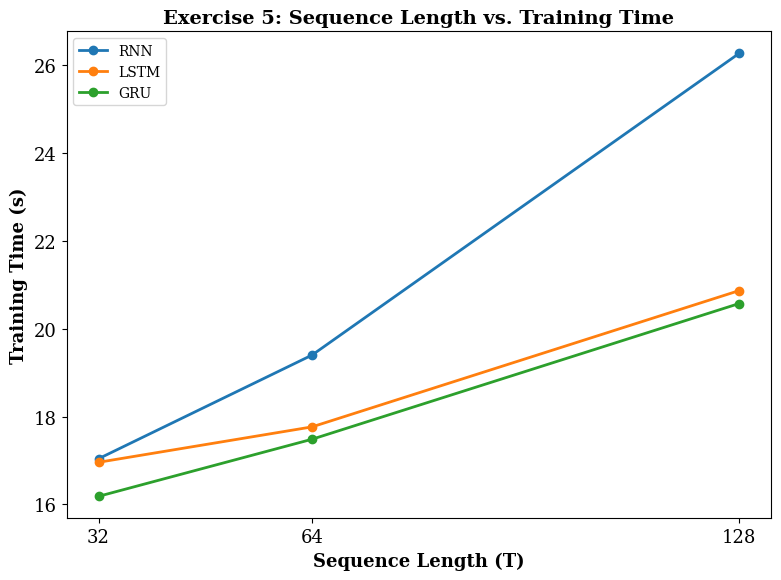

In [29]:
ex5_results = []
for T_len in seq_lengths:
    Xtr_t = truncate_seq(X_train, T_len)
    Xval_t = truncate_seq(X_val, T_len)
    for rtype in ["RNN", "LSTM", "GRU"]:
        clear_mem()
        m = build_model(rtype, units=32, input_shape=(T_len, F_CH))
        start = time.time()
        m.fit(Xtr_t, y_train, validation_data=(Xval_t, y_val), epochs=30, batch_size=32, verbose=0)
        elapsed = time.time() - start
        ex5_results.append({"Sequence Length": T_len, "Model": rtype,
                             "Parameters": m.count_params(), "Training Time (s)": elapsed})
        print(f"T={T_len:3d} | {rtype:5s} | Time={elapsed:.1f}s Params={m.count_params()}")

ex5_table = pd.DataFrame(ex5_results)
ex5_table.to_csv(os.path.join(OUT_DIR, "exercise5_seqlen_vs_cost.csv"), index=False)

fig, ax = plt.subplots(figsize=(8, 6))
for rtype in ["RNN", "LSTM", "GRU"]:
    sub = ex5_table[ex5_table["Model"] == rtype]
    ax.plot(sub["Sequence Length"], sub["Training Time (s)"], marker='o', linewidth=2, label=rtype)
ax.set_xlabel("Sequence Length (T)", fontweight='bold', fontsize=13)
ax.set_ylabel("Training Time (s)", fontweight='bold', fontsize=13)
ax.set_title("Exercise 5: Sequence Length vs. Training Time", fontweight='bold', fontsize=14)
ax.set_xticks(seq_lengths)
ax.legend(fontsize=10)
style_axes(ax)
fig.tight_layout()
savefig(fig, "exercise5_seqlen_vs_cost.png")

### 24.6 Exercise 6 — Video Task: LSTM vs. GRU on Identical CNN Features

In [30]:
ex6_results = []
for rtype in ["LSTM", "GRU"]:
    clear_mem()
    m = build_video_model(rtype, units=32)
    start = time.time()
    m.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val), epochs=30, batch_size=8, verbose=0)
    elapsed = time.time() - start
    y_prob = m.predict(Xv_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(yv_test, y_pred) * 100
    _, _, f1, _ = precision_recall_fscore_support(yv_test, y_pred, average='macro', zero_division=0)
    ex6_results.append({"Model": f"CNN-{rtype}", "Accuracy (%)": acc, "F1 (%)": f1 * 100,
                         "Parameters": m.count_params(), "Training Time (s)": elapsed})
    print(f"CNN-{rtype} | Acc={acc:.2f}% F1={f1*100:.2f}%")

ex6_table = pd.DataFrame(ex6_results)
ex6_table.to_csv(os.path.join(OUT_DIR, "exercise6_video_lstm_vs_gru.csv"), index=False)
display(ex6_table)

CNN-LSTM | Acc=93.10% F1=92.91%
CNN-GRU | Acc=96.55% F1=96.64%


,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,CNN-LSTM,93.103448,92.905983,168229,6.763077
1,CNN-GRU,96.551724,96.643357,126309,6.688736


### 24.7 Exercise 7 — Seq2Seq With Output Sequence Length Different From Input

In [31]:
# Modify the task: input length 4, output length 2 (first half of the reversed sequence)
IN_LEN, OUT_LEN = 4, 2

def generate_variable_length_data(n_samples, in_len, out_len):
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, in_len))
    Y = X[:, ::-1][:, :out_len].copy()  # reversed sequence, truncated to out_len
    return X, Y

X_v, Y_v = generate_variable_length_data(NUM_SAMPLES, IN_LEN, OUT_LEN)
dec_input_v = np.concatenate([np.full((NUM_SAMPLES, 1), SOS_TOKEN), Y_v[:, :-1]], axis=1)

Xv2_train, Xv2_temp, decv2_train, decv2_temp, Yv2_train, Yv2_temp = train_test_split(
    X_v, dec_input_v, Y_v, test_size=0.30, random_state=SEED)
Xv2_val, Xv2_test, decv2_val, decv2_test, Yv2_val, Yv2_test = train_test_split(
    Xv2_temp, decv2_temp, Yv2_temp, test_size=0.50, random_state=SEED)

def build_seq2seq_variable(in_len, out_len):
    encoder_inputs = layers.Input(shape=(in_len,))
    enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True)(encoder_inputs)
    _, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)
    encoder_states = [state_h, state_c]

    decoder_inputs = layers.Input(shape=(out_len,))
    dec_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True)(decoder_inputs)
    decoder_outputs, _, _ = layers.LSTM(ENC_UNITS, return_sequences=True, return_state=True)(
        dec_emb, initial_state=encoder_states)
    decoder_outputs = layers.Dense(VOCAB_SIZE, activation='softmax')(decoder_outputs)

    model = models.Model([encoder_inputs, decoder_inputs], decoder_outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clear_mem()
seq2seq_var_model = build_seq2seq_variable(IN_LEN, OUT_LEN)
seq2seq_var_model.summary()
seq2seq_var_history = seq2seq_var_model.fit(
    [Xv2_train, decv2_train], Yv2_train,
    validation_data=([Xv2_val, decv2_val], Yv2_val),
    epochs=30, batch_size=64, verbose=1)

print(f"\nInput length: {IN_LEN}, Output length: {OUT_LEN}")
print(f"Final Training Loss  : {seq2seq_var_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {seq2seq_var_history.history['val_loss'][-1]:.4f}")
print(f"Example -> Input: {X_v[0]}  Output: {Y_v[0]}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        352 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4)         │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 2, 32)     │        352 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     24,832 │ embedding[0][0],  │
│                     │ (None, 64),       │            │ not_equal[0][0]   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 2, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2, 11)     │        715 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2844 - loss: 2.2095 - val_accuracy: 0.4367 - val_loss: 1.8203
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5069 - loss: 1.4013 - val_accuracy: 0.5940 - val_loss: 1.0430
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6884 - loss: 0.7973 - val_accuracy: 0.8087 - val_loss: 0.5586
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9143 - loss: 0.3696 - val_accuracy: 0.9753 - val_loss: 0.2193
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9963 - loss: 0.1382 - val_accuracy: 0.9993 - val_loss: 0.0859
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0604 - val_accuracy: 1.0000 - val_loss: 0.0445
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0345 - val_accuracy: 1.0000 - val_loss: 0.0281
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss